In [13]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
from pathlib import Path

In [14]:
# Setup logging
log_dir = Path("../logs")
log_dir.mkdir(exist_ok=True)
logging.basicConfig(
    filename=log_dir / "data_missing_values_log.txt",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [15]:
# Create figures directory
figures_dir = Path("../data/figures")
figures_dir.mkdir(exist_ok=True)

In [16]:
# Log notebook start
logging.info("Starting missing values analysis for content and traffic datasets")

In [17]:
# Datasets to analyze
datasets = {
    "content/Chart data.csv": "../data/raw/content/Chart data.csv",
    "content/Totals.csv": "../data/raw/content/Totals.csv",
    "content/Table data.csv": "../data/raw/content/Table data.csv",
    "traffic/Chart data.csv": "../data/raw/traffic/Chart data.csv",
    "traffic/Totals.csv": "../data/raw/traffic/Totals.csv",
    "traffic/Table data.csv": "../data/raw/traffic/Table data.csv"
}


--- content/Chart data.csv Missing Values Sorted ---

Sorted by Video publish time (missing values first):
            Date       Content Video publish time
0     2021-07-16   -e0JZNRR-QA                NaN
4449  2021-07-16   DYK2HKo-aco                NaN
4450  2021-07-17   DYK2HKo-aco                NaN
1     2021-07-17   -e0JZNRR-QA                NaN
2     2021-07-18   -e0JZNRR-QA                NaN
4451  2021-07-18   DYK2HKo-aco                NaN
3     2021-07-19   -e0JZNRR-QA                NaN
4452  2021-07-19   DYK2HKo-aco                NaN
4     2021-07-20   -e0JZNRR-QA                NaN
4453  2021-07-20   DYK2HKo-aco                NaN

Sorted by Average percentage viewed (%) (missing values first):
            Date      Content  Average percentage viewed (%)
2621  2024-08-27  25Txzdyd3Yo                            NaN
2681  2024-10-26  25Txzdyd3Yo                            NaN
2802  2025-02-24  25Txzdyd3Yo                            NaN
2806  2025-02-28  25Txzdyd3Yo    

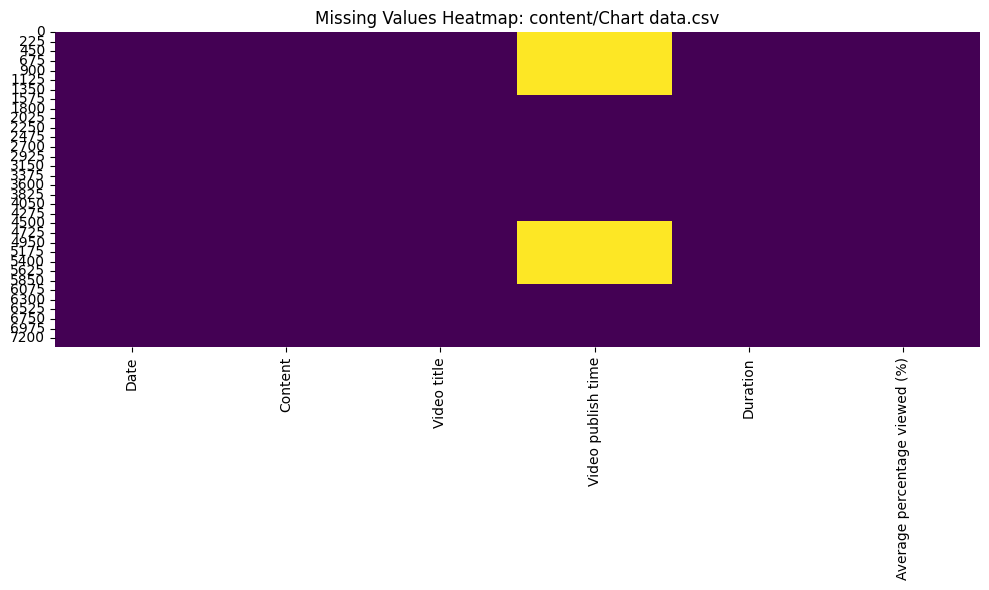

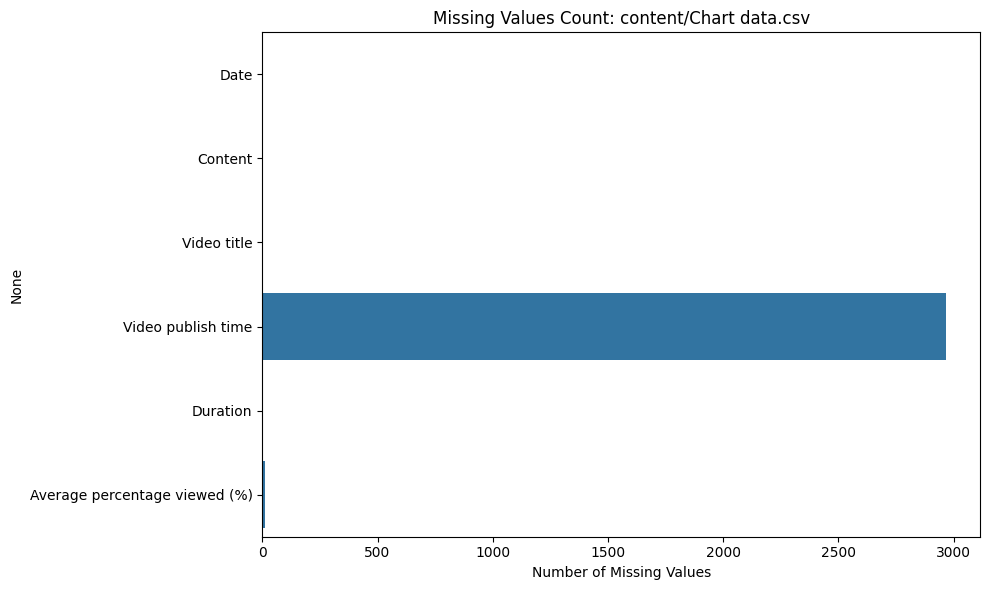


--- content/Totals.csv Missing Values Sorted ---

Sorted by Average percentage viewed (%) (missing values first):
            Date  Average percentage viewed (%)
78    2021-10-02                            NaN
105   2021-10-29                            NaN
593   2023-03-01                            NaN
699   2023-06-15                            NaN
1115  2024-08-04                            NaN


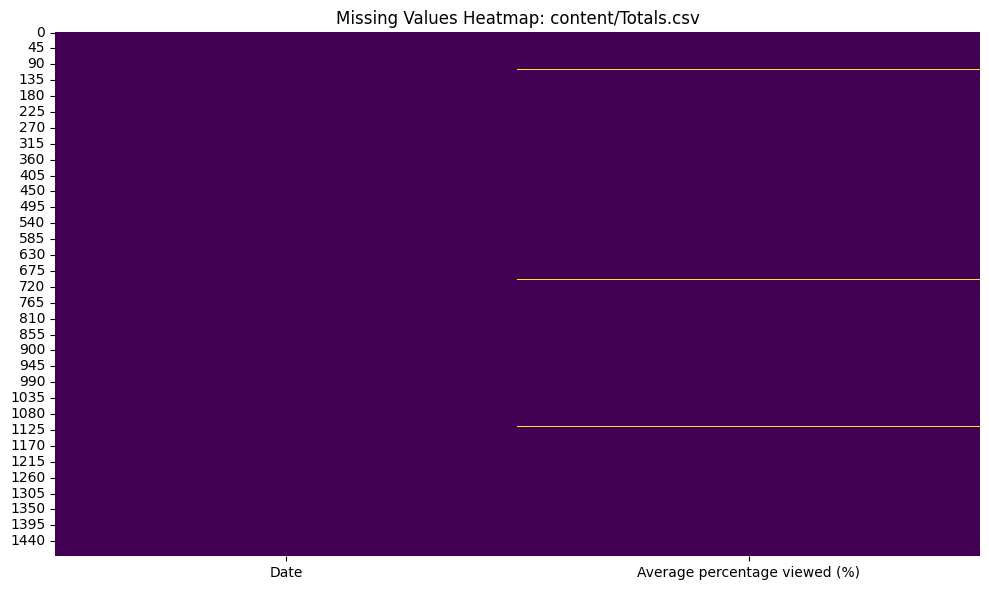

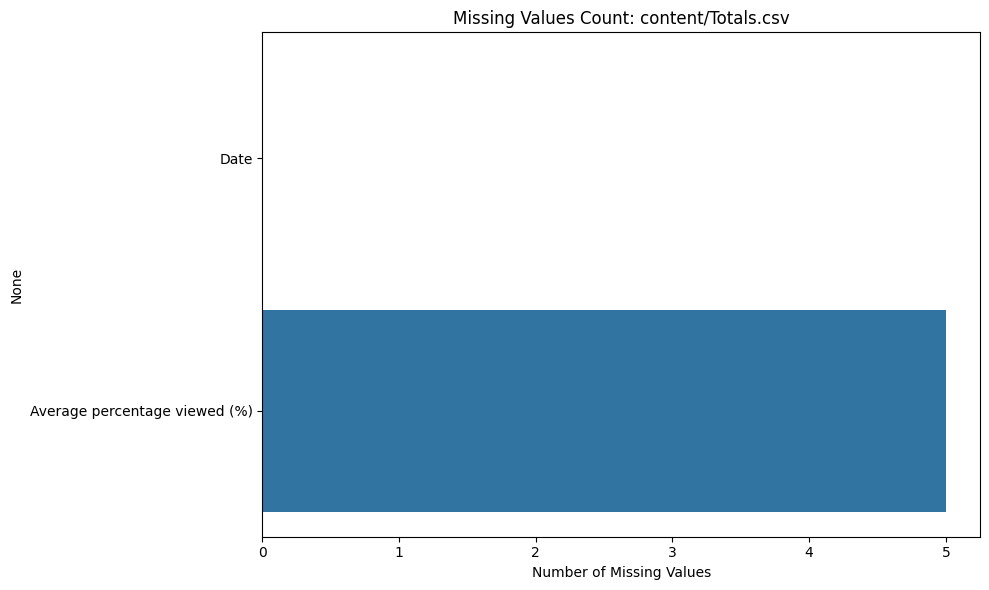


--- content/Table data.csv Missing Values Sorted ---

Sorted by Video title (missing values first):
  Content Video title
0   Total         NaN

Sorted by Video publish time (missing values first):
         Content Video publish time
22   -ErzNW5H7Ks                NaN
3    -e0JZNRR-QA                NaN
23   08np20KYF08                NaN
24   1Rg4g-EP_9c                NaN
26   46ZRM3aVGAw                NaN
28   4imy1oKebR0                NaN
30   4nv-6OYuoOY                NaN
31   5ftGj0_tSmw                NaN
32   5sWMgDHIQ2E                NaN
33   6WLbWyWYanw                NaN

Sorted by Duration (missing values first):
  Content  Duration
0   Total       NaN

Sorted by Regular viewers (missing values first):
         Content  Regular viewers
22   -ErzNW5H7Ks              NaN
3    -e0JZNRR-QA              NaN
23   08np20KYF08              NaN
24   1Rg4g-EP_9c              NaN
25   1muTtvQdDa0              NaN
4    25Txzdyd3Yo              NaN
26   46ZRM3aVGAw              Na

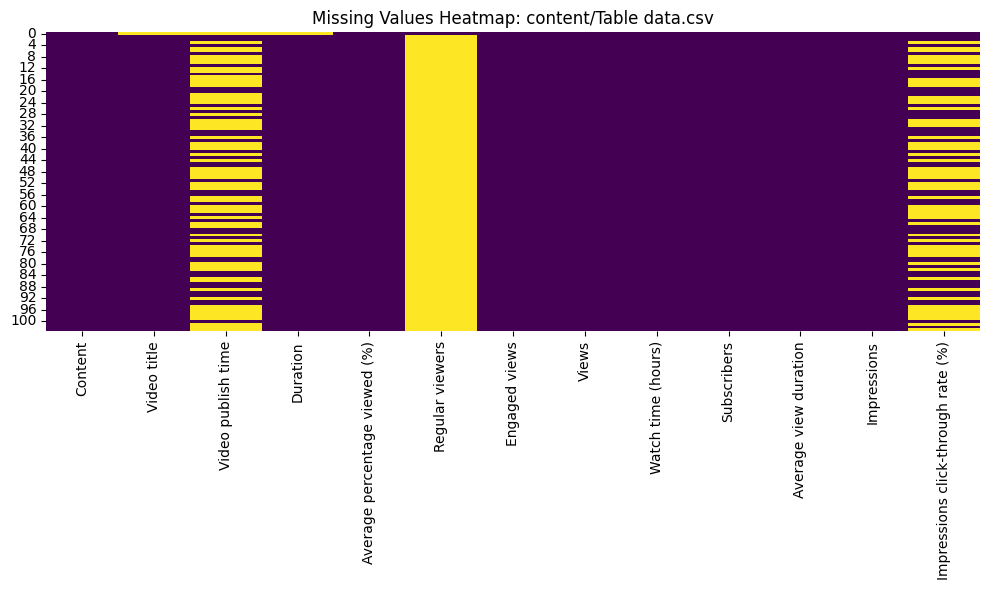

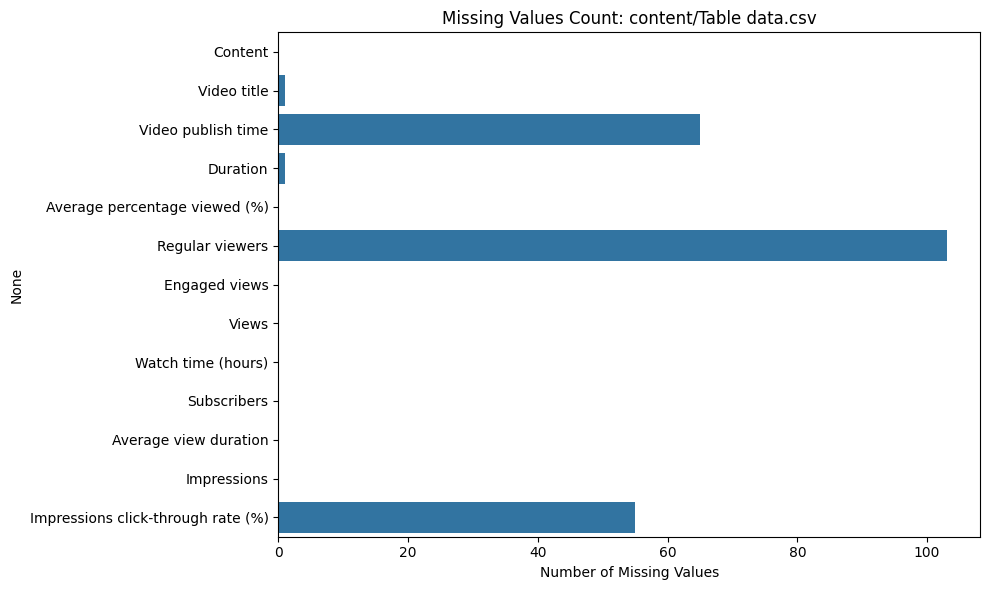

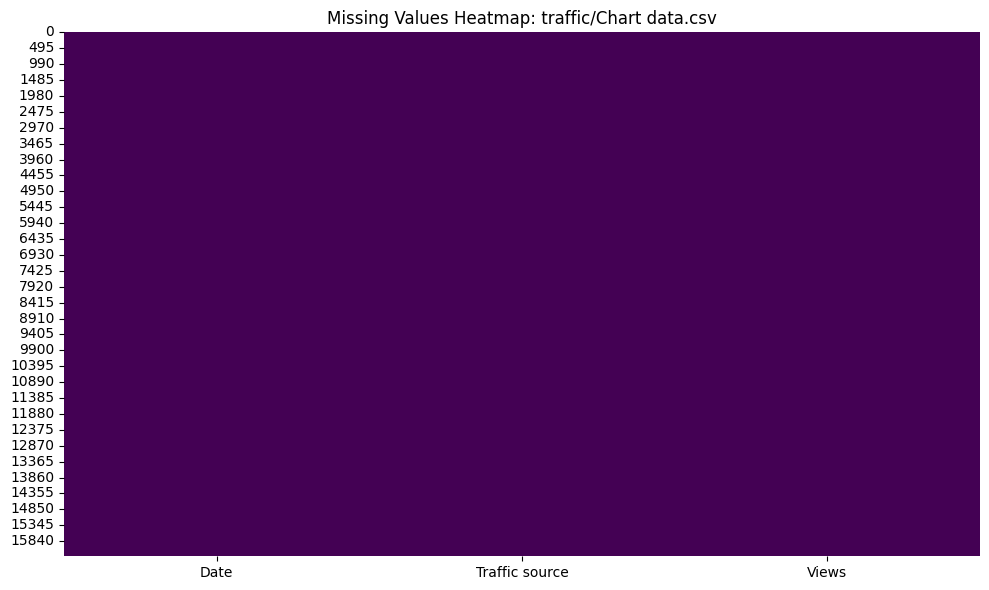

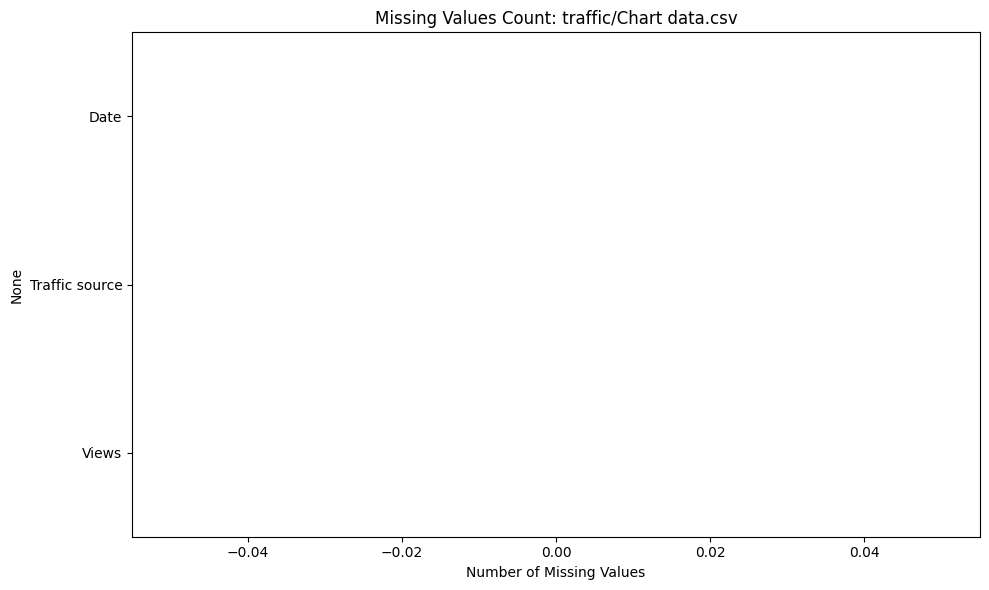

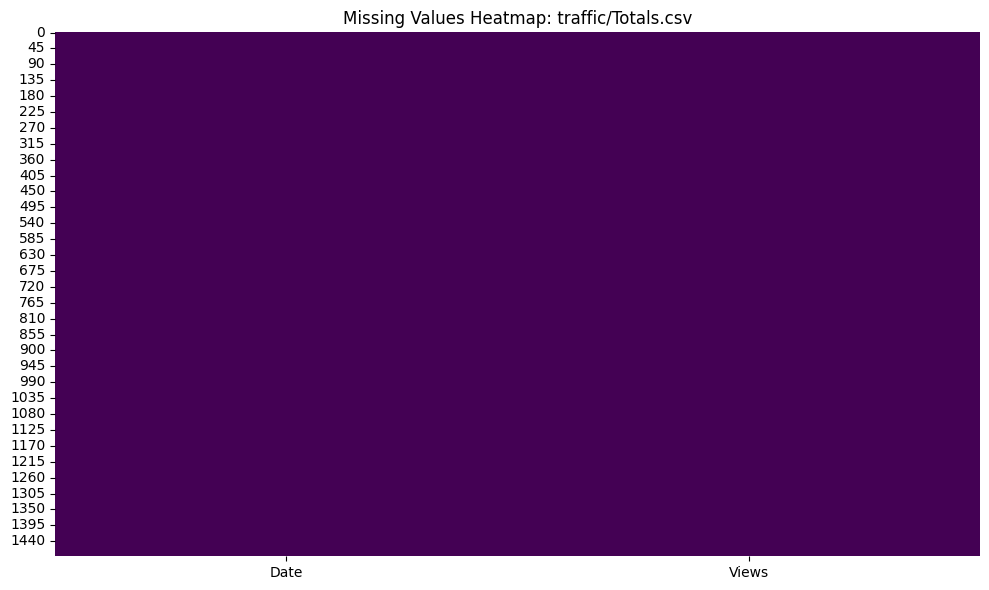

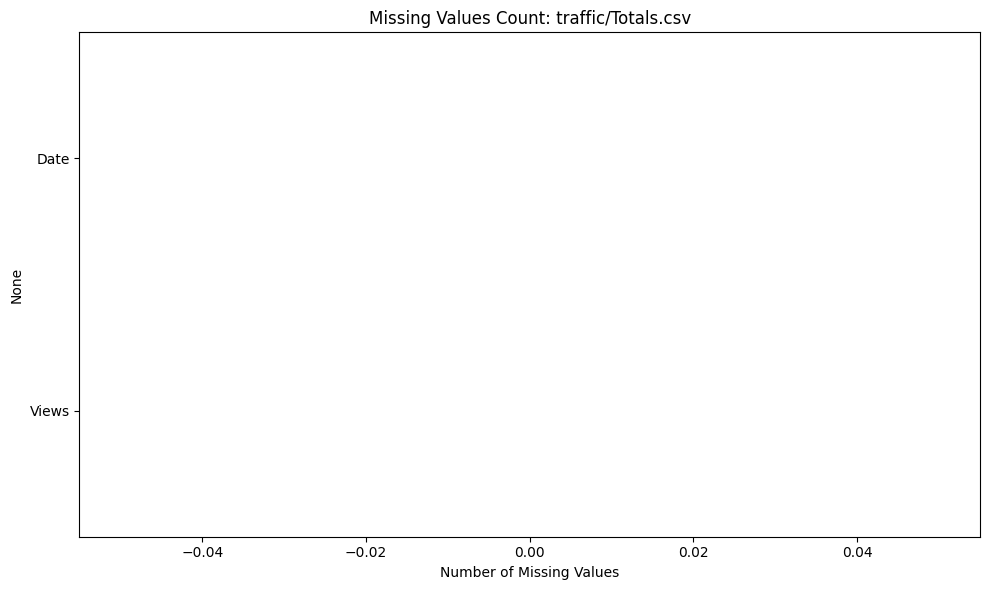


--- traffic/Table data.csv Missing Values Sorted ---

Sorted by Impressions (missing values first):
            Traffic source  Impressions
4        Direct or unknown          NaN
11             End screens          NaN
2                 External          NaN
10           Notifications          NaN
6   Other YouTube features          NaN
8              Shorts feed          NaN

Sorted by Impressions click-through rate (%) (missing values first):
            Traffic source  Impressions click-through rate (%)
4        Direct or unknown                                 NaN
11             End screens                                 NaN
2                 External                                 NaN
10           Notifications                                 NaN
6   Other YouTube features                                 NaN
8              Shorts feed                                 NaN


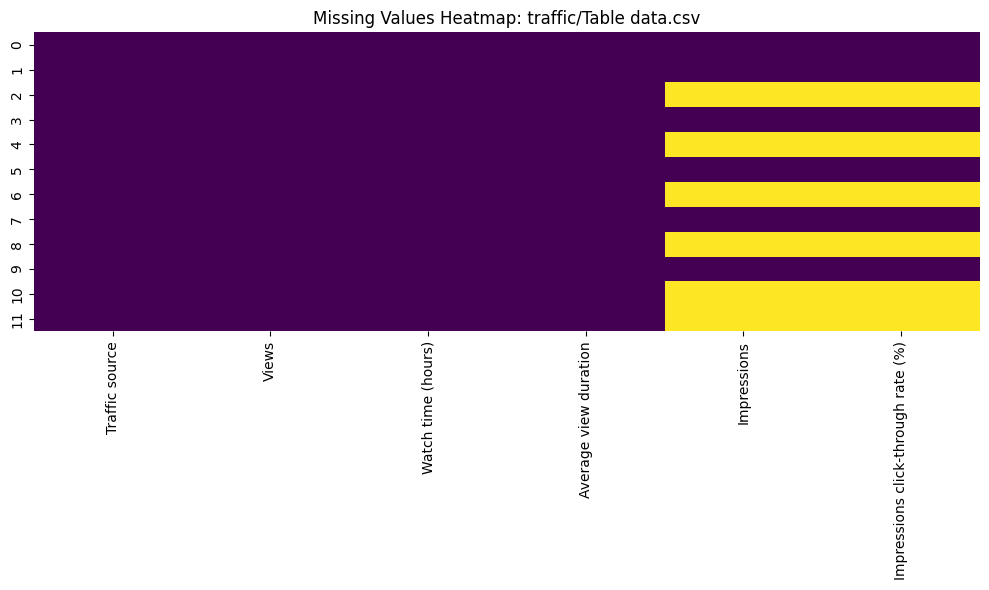

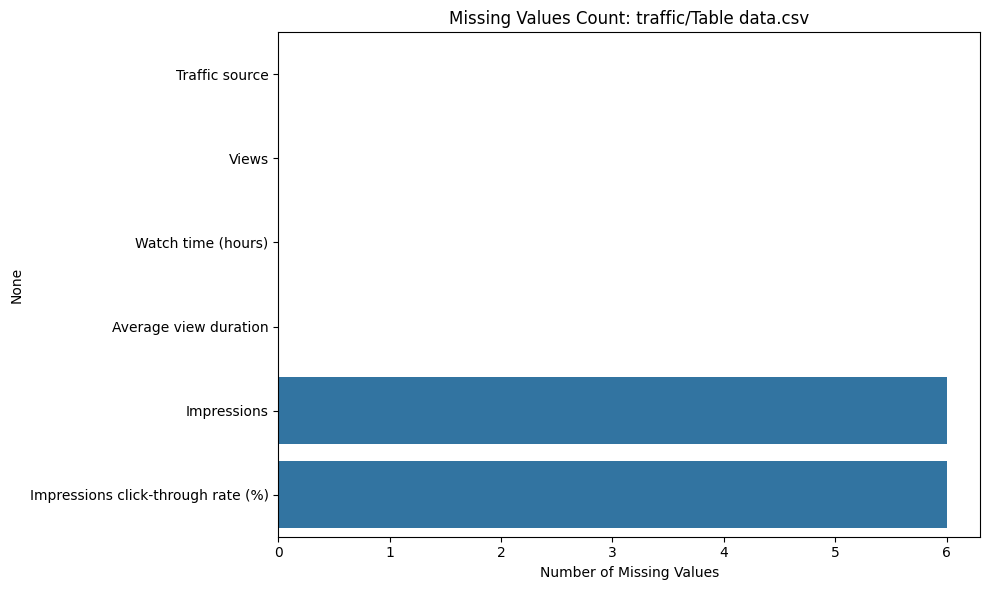

In [18]:
for name, path in datasets.items():
    try:
        df = pd.read_csv(path)
        logging.info(f"Loaded {name} for missing values analysis")
        
        # Identify available columns for sorting
        available_cols = df.columns.tolist()
        sort_cols = []
        if 'Date' in available_cols:
            sort_cols.append('Date')
        if 'Content' in available_cols:
            sort_cols.append('Content')
        if 'Traffic source' in available_cols:
            sort_cols.append('Traffic source')
        if not sort_cols:
            sort_cols = available_cols[:2]  # Fallback to first two columns
        
        # Sort by columns with missing values
        missing_cols = df.columns[df.isnull().any()].tolist()
        if missing_cols:
            print(f"\n--- {name} Missing Values Sorted ---")
            for col in missing_cols:
                print(f"\nSorted by {col} (missing values first):")
                print(df[df[col].isnull()][sort_cols + [col]].sort_values(by=sort_cols[:1]).head(10))
        
        # Visualize missing values
        plt.figure(figsize=(10, 6))
        sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
        plt.title(f"Missing Values Heatmap: {name}")
        plt.tight_layout()
        plt.savefig(f"../data/figures/missing_values_heatmap_{name.replace('/', '_').replace('.csv', '.png')}")
        plt.show()
        logging.info(f"Saved missing values heatmap for {name}")
        
        # Missing values count plot
        plt.figure(figsize=(10, 6))
        missing_counts = df.isnull().sum()
        sns.barplot(x=missing_counts.values, y=missing_counts.index)
        plt.title(f"Missing Values Count: {name}")
        plt.xlabel("Number of Missing Values")
        plt.tight_layout()
        plt.savefig(f"../data/figures/missing_values_count_{name.replace('/', '_').replace('.csv', '.png')}")
        plt.show()
        logging.info(f"Saved missing values count plot for {name}")
        
        logging.info(f"Missing values in {name}: {df.isnull().sum().to_dict()}")
    except Exception as e:
        logging.error(f"Error analyzing {name}: {str(e)}")